<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-12</br>
</div>

</br>

In [ ]:
# TODO 0: 실습을 위해 아래 패키지를 import 해주세요.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


class MLP(nn.Module):

    def __init__(self, input_dim, num_classes, hidden_dims=(128, 64), dropout=0.2):
        super().__init__()
        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, input_tensor):
        return self.network(input_tensor)

</br>

# 학습 내용
>이번 장에서는 <strong>결정 경계 시각화(Decision Boundary Visualization)</strong>에 대해 학습합니다.</br></br>
>2D 데이터에서 모델이 학습한 분류 영역을 시각적으로 확인하는 방법을 학습해봅시다.

</br>

# 결정 경계 시각화 (Decision Boundary)
> 2D 데이터를 사용하여 모델이 학습한 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">분류 영역을 시각적으로 확인</mark>합니다.

> 결정 경계(Decision Boundary)는 모델이 각 클래스를 나누는 경계선입니다.</br></br>
> 2D 데이터에서는 평면 위의 선으로 나타나며, 이를 통해 모델이 데이터의 패턴을 얼마나 잘 학습했는지 직관적으로 확인할 수 있습니다.

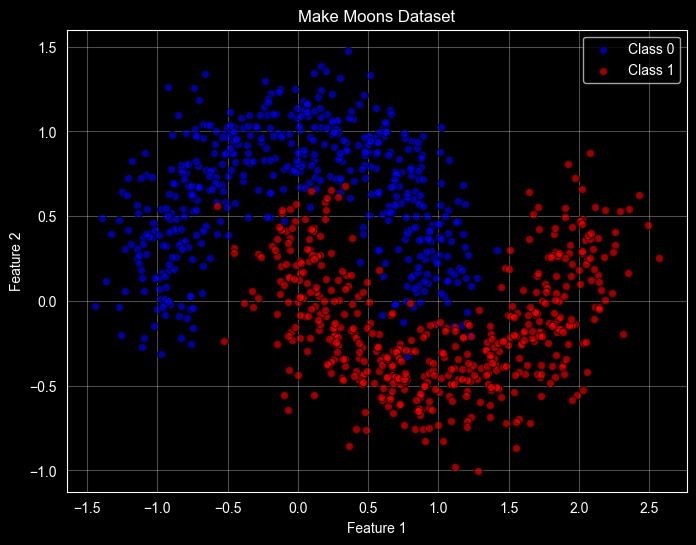

In [11]:
# TODO 1: make_moons 데이터셋을 생성하고 시각화해봅시다.

moons_features, moons_target = make_moons(n_samples=1000, noise=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(moons_features[moons_target == 0, 0], moons_features[moons_target == 0, 1],
            c="blue", label="Class 0", alpha=0.6, edgecolors="k")
plt.scatter(moons_features[moons_target == 1, 0], moons_features[moons_target == 1, 1],
            c="red", label="Class 1", alpha=0.6, edgecolors="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make Moons Dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# TODO 2: 데이터를 학습용과 테스트용으로 분할해봅시다. (test_size=0.2, random_state=42, stratify=moons_target)

moons_train_features, moons_test_features, moons_train_target, moons_test_target = train_test_split(
    moons_features, moons_target, test_size=0.2, random_state=42, stratify=moons_target
)

print(f"학습 데이터: {moons_train_features.shape}, 테스트 데이터: {moons_test_features.shape}")

In [ ]:
# TODO 3: StandardScaler로 학습 데이터를 표준화하고, 테스트 데이터에는 transform만 적용해봅시다.

moons_scaler = StandardScaler()
moons_train_scaled = moons_scaler.fit_transform(moons_train_features)
moons_test_scaled = moons_scaler.transform(moons_test_features)

print(f"스케일링 후 - 평균: {moons_train_scaled.mean(axis=0).round(2)}, 표준편차: {moons_train_scaled.std(axis=0).round(2)}")

In [ ]:
# TODO 4: DataLoader를 생성해봅시다. (batch_size=32, shuffle=True)

moons_train_loader = DataLoader(
    TensorDataset(torch.from_numpy(moons_train_scaled).float(), torch.from_numpy(moons_train_target).long()),
    batch_size=32, shuffle=True
)

print(f"학습 배치 수: {len(moons_train_loader)}")

In [ ]:
# TODO 5: SimplePerceptron 모델(input_dim=2, num_classes=2, hidden_dims=(16,), dropout=0.0)을 생성해봅시다.

simple_perceptron = MLP(input_dim=2, num_classes=2, hidden_dims=(16,), dropout=0.0)
print(simple_perceptron)

In [ ]:
# TODO 6: 손실 함수와 옵티마이저(lr=0.01)를 설정해봅시다.

moons_criterion = nn.CrossEntropyLoss()
moons_optimizer = optim.Adam(simple_perceptron.parameters(), lr=0.01)

In [ ]:
# TODO 7: 100 에폭 동안 모델을 학습시켜봅시다.

for epoch in range(100):
    simple_perceptron.train()
    for features_batch, target_batch in moons_train_loader:
        moons_optimizer.zero_grad()
        output = simple_perceptron(features_batch)
        loss = moons_criterion(output, target_batch)
        loss.backward()
        moons_optimizer.step()

simple_perceptron.eval()
print("SimplePerceptron 학습 완료!")

In [ ]:
# TODO 8: 결정 경계를 시각화해봅시다.

def plot_decision_boundary(model, features, target, scaler, title="Decision Boundary"):
    model.eval()
    h = 0.02
    x_min, x_max = features[:, 0].min() - 1, features[:, 0].max() + 1
    y_min, y_max = features[:, 1].min() - 1, features[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_points)
    grid_tensor = torch.from_numpy(grid_scaled).float()

    with torch.no_grad():
        outputs = model(grid_tensor)
        _, predictions = outputs.max(1)

    predictions = predictions.numpy().reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, predictions, alpha=0.4, cmap="RdYlBu")
    plt.scatter(features[target == 0, 0], features[target == 0, 1],
                c="blue", label="Class 0", edgecolors="k", s=50, alpha=0.7)
    plt.scatter(features[target == 1, 0], features[target == 1, 1],
                c="red", label="Class 1", edgecolors="k", s=50, alpha=0.7)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(simple_perceptron, moons_train_features, moons_train_target,
                       moons_scaler, "Decision Boundary (Training Set)")
plot_decision_boundary(simple_perceptron, moons_test_features, moons_test_target,
                       moons_scaler, "Decision Boundary (Test Set)")

💡결정 경계 해석
> **비선형 경계**: MLP는 ReLU 활성화 함수 덕분에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">곡선 형태의 결정 경계</mark>를 학습할 수 있습니다.</br>
> **단순 선형 모델과의 차이**: 로지스틱 회귀는 직선으로만 분류하지만, MLP는 비선형 데이터(make_moons)도 정확히 분류합니다.</br>
> **과적합 확인**: 학습 데이터의 결정 경계가 너무 복잡하면(울퉁불퉁) 과적합일 수 있습니다.